# ATF Case: LWIR Laser–Plasma Interaction

This notebook analyzes an ATF-relevant laser–plasma case with parameters corresponding to a long-wavelength infrared driver:

$$
n_e = 2 \times 10^{16}\ \mathrm{cm^{-3}},
\quad \lambda_0 = 9.2\ \mu\mathrm{m},
\quad w_0 = 75\ \mu\mathrm{m},
\quad a_0 = 3.26,
\quad \tau_{FWHM} = 500\ \mathrm{fs}.
$$

In normalized plasma units, these parameters correspond to

$$
k_p w_0 = 1.99,
\quad k_p c \tau = 3.98.
$$

This case represents an upgraded ATF-like operating point for a CO\(_2\)-laser-driven plasma wakefield interaction. 

This notebook calculates and visualizes a **single-electron trajectory** in the wakefield generated by this ATF parameter set. It is intended as a lightweight case for inspecting the fields, forces, and particle motion for one representative test electron. Multi-electron trajectory tracking with multi-core processing on a personal computer is available in the `ATF2e16_multi-processing` notebook in the same folder.

In [144]:
from pathlib import Path
import os
import sys

core_name = "ATF2e16_M1_x-2"

project_root = Path.cwd().resolve()

while not (project_root / "main.py").exists():
    if project_root == project_root.parent:
        raise RuntimeError("Could not find QuEP project root containing main.py.")
    project_root = project_root.parent

os.chdir(project_root)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Working directory set to:", project_root)

Working directory set to: /Users/navidv/GitHub/QuEP


In [145]:
# This cell creates a Python input file in the subfolder input/.

input_text = f"""
# Auto-generated by {core_name}_single_track notebook.

simulation_name = "QUASI3D"

shape = "single"

iterations = 150000

# mode 0 is the wakefield, mode 1 is the laser, mode -1 is both.
mode = 1

fname = "{core_name}.npz"

debugmode = True

# Probe centered at the following initial coordinates, in c/omega_p.
x_c = 2
y_c = 0
xi_c = 6

# Initial momentum.
px_0 = 0
py_0 = 0
pz_0 = 0

# Screen distances from z-axis of plasma cell, in mm.
x_s = [10, 50, 100, 250, 500]

# Shape parameters.
s1 = 1  # in y
s2 = 1  # in xi

# Densities.
ydensity = 1
xidensity = 1
xdensity = 1
resolution = None

# Quasi3D simulation parameters.
quasi_id = "000026"
quasi_data_dir = "data/OSIRIS/ATF2e16"
quasi_density = 2e22
quasi_propagation_speed = 1.0
dt_safety_factor = 0.1
"""

input_path = project_root / "input" / f"{core_name}.py"
input_path.write_text(input_text.strip() + "\n")

print(f"Wrote {input_path}")

Wrote /Users/navidv/GitHub/QuEP/input/ATF2e16_M1_x-2.py


In [146]:
#Run first cell to change into the project root directory
%reset -f
%run main.py input.ATF2e16_M1_x-2

Start Time:  08:56:19
Using initial conditions from  input.ATF2e16_M1_x-2
Using laser vector-potential region:
  xi range: -12.005749999999999 9.999749999999999
  index range: 0 3999
Probe initialized...
Number of objects: 1
Using laser vector-potential region:
  xi range: -12.005749999999999 9.999749999999999
  index range: 0 3999
Using Debug Mode...
Tracking quit due to particle leaving cell
Debug object created...
End Time:  08:56:36
Duration:  0.29801351626714073  min
Debug object saved to data/ATF2e16_M1_x-2-DEBUG.obj


In [147]:
#This cell is intended to be able to load everything independently.
#so you need to enter the core_name again
%reset -f

core_name = "ATF2e16_M1_x-2"

import gc
import importlib
import pickle
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Clean up memory from earlier notebook cells.
gc.collect()

# Make sure imports work when the notebook is run from the project root.
project_root = Path.cwd()
print("Working directory set to:", project_root)

# -----------------------------------------------------------------------------
# Load the user input file
# -----------------------------------------------------------------------------
# Use the module name, not the .py or .npz filename.
# For input/betatron_tutorial_input.py, use "input.betatron_tutorial_input" if
input_module = f"input.{core_name}"
init = importlib.import_module(input_module)

# -----------------------------------------------------------------------------
# Configure the Quasi3D field infrastructure
# -----------------------------------------------------------------------------
import include.simulations.useQuasi3D as sim
sim.configure(init)

# -----------------------------------------------------------------------------
# Load the debug trajectory object
# -----------------------------------------------------------------------------
debug_file = project_root / "data" / f"{core_name}-DEBUG.obj"

with open(debug_file, "rb") as file:
    debug_loaded = pickle.load(file)

# main.py saves Debug as a one-element list/tuple in this tutorial case.
debug = debug_loaded[0] if isinstance(debug_loaded, (list, tuple)) else debug_loaded

print(f"Loaded input module: {init.__name__}")
print(f"Loaded debug file:   {debug_file}")
print("\nThe Debug object contains the following saved simulation quantities:")
for key, value in debug.__dict__.items():
    print(f"{key:20s}  type={type(value).__name__:15s}  shape={np.shape(value)}")

Working directory set to: /Users/navidv/GitHub/QuEP
Using laser vector-potential region:
  xi range: -12.005749999999999 9.999749999999999
  index range: 0 3999
Loaded input module: input.ATF2e16_M1_x-2
Loaded debug file:   /Users/navidv/GitHub/QuEP/data/ATF2e16_M1_x-2-DEBUG.obj

The Debug object contains the following saved simulation quantities:
x_dat                 type=ndarray          shape=(1, 24680)
y_dat                 type=ndarray          shape=(1, 24680)
z_dat                 type=ndarray          shape=(1, 24680)
xi_dat                type=ndarray          shape=(1, 24680)
Fx_dat                type=ndarray          shape=(1, 24680)
Fy_dat                type=ndarray          shape=(1, 24680)
Fz_dat                type=ndarray          shape=(1, 24680)
px_dat                type=ndarray          shape=(1, 24680)
py_dat                type=ndarray          shape=(1, 24680)
pz_dat                type=ndarray          shape=(1, 24680)


In [148]:
#Defining functions that allows fields to be called as needed
def as_2d(arr):
    """Return an array with shape (n_particles, n_steps)."""
    arr = np.asarray(arr)
    if arr.ndim == 1:
        return arr[None, :]
    return arr


def get_r_xi_from_debug(debug):
    """Extract r and xi trajectory arrays from a DebugObject."""
    x_dat = as_2d(debug.x_dat)
    y_dat = as_2d(debug.y_dat)
    xi_dat = as_2d(debug.xi_dat)

    r_dat = np.sqrt(x_dat**2 + y_dat**2)
    return r_dat, xi_dat


def symmetric_color_limits(field, percentile=99):
    """Choose symmetric color limits using a percentile to avoid outlier domination."""
    vmax = np.nanpercentile(np.abs(field), percentile)
    return -vmax, vmax


def plot_field_with_debug_trajectories(
    xi_axis,
    r_axis,
    field,
    debug,
    *,
    title,
    field_label,
    xlim=None,
    ylim=None,
    vmin=None,
    vmax=None,
    cmap="RdBu_r",
):
    """Plot a Quasi3D field in (xi, r) and overlay debug trajectories."""
    r_dat, xi_dat = get_r_xi_from_debug(debug)

    if vmin is None or vmax is None:
        auto_vmin, auto_vmax = symmetric_color_limits(field)
        vmin = auto_vmin if vmin is None else vmin
        vmax = auto_vmax if vmax is None else vmax

    fig, ax = plt.subplots(figsize=(9, 5), dpi=130)

    mesh = ax.pcolormesh(
        xi_axis,
        r_axis,
        field,
        shading="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )

    for i in range(r_dat.shape[0]):
        ax.plot(
            xi_dat[i, :],
            r_dat[i, :],
            color="black",
            linewidth=1.5,
            label="debug trajectory" if i == 0 else None,
        )

    ax.set_xlabel(r"$\xi$ $(c/\omega_p)$")
    ax.set_ylabel(r"$r$ $(c/\omega_p)$")
    ax.set_title(title)

    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)

    if r_dat.shape[0] > 0:
        ax.legend(loc="best")

    cbar = fig.colorbar(mesh, ax=ax)
    cbar.set_label(field_label)

    fig.tight_layout()
    plt.show()


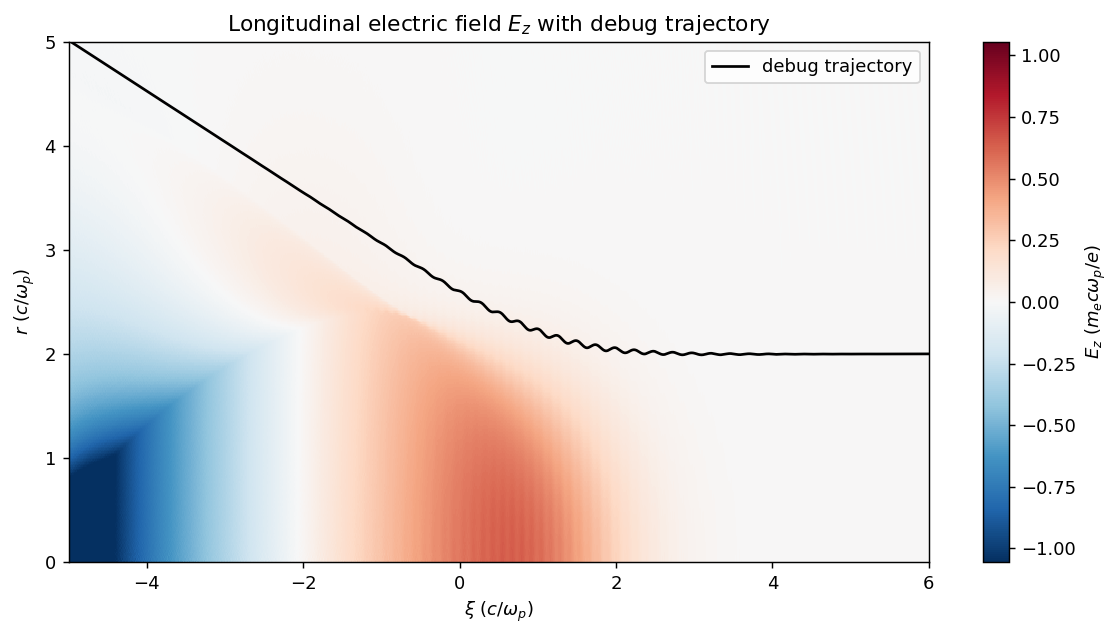

In [149]:
# Longitudinal electric field with the debug trajectory overlaid.
# E1_M0 lives on (xiaxis_1, raxis_2).
plot_field_with_debug_trajectories(
    sim.xiaxis_1,
    sim.raxis_2,
    sim.E1_M0,
    debug,
    title=r"Longitudinal electric field $E_z$ with debug trajectory",
    field_label=r"$E_z$ $(m_e c \omega_p/e)$",
    xlim=(-5, 6),
    # xlim=(1, 3),
    ylim=(0, 5),
    # vmin=0.5,
    # vmax=0.7
)

In [150]:
# Defining functions that allow fields and debug trajectories to be called as needed.

def as_2d(arr):
    """Return an array with shape (n_particles, n_steps)."""
    arr = np.asarray(arr)
    if arr.ndim == 1:
        return arr[None, :]
    return arr


def get_debug_quantity(debug, quantity):
    """
    Extract a trajectory quantity from one DebugObject.

    quantity can be:
        - "xi_dat", "x_dat", "y_dat", "Fx_dat", "Fy_dat", etc.
        - "r_dat" for sqrt(x_dat^2 + y_dat^2)
        - a function, e.g. lambda debug: debug.Fx_dat + debug.Fy_dat
    """
    #callable is used to return a custom variable defined by a function
    if callable(quantity):
        return as_2d(quantity(debug))

    if quantity == "r_dat":
        x_dat = as_2d(debug.x_dat)
        y_dat = as_2d(debug.y_dat)
        return np.sqrt(x_dat**2 + y_dat**2)

    if not hasattr(debug, quantity):
        raise AttributeError(f"Debug object does not have attribute '{quantity}'.")

    return as_2d(getattr(debug, quantity))


def symmetric_color_limits(field, percentile=99):
    """Choose symmetric color limits using a percentile to avoid outlier domination."""
    vmax = np.nanpercentile(np.abs(field), percentile)
    return -vmax, vmax


def plot_field_with_debug_trajectories(
    xi_axis=None,
    y_axis=None,
    field=None,
    debug_objects=None,
    *,
    trajectory_quantity="r_dat",
    trajectory_label=None,
    xi_quantity="xi_dat",
    title,
    field_label=None,
    xlim=None,
    ylim=None,
    vmin=None,
    vmax=None,
    cmap="RdBu_r",
    show_field=True,
):
    """
    Plot debug trajectories versus xi.

    If field, xi_axis, and y_axis are provided and show_field=True,
    the function also plots the field as a background pcolormesh.

    trajectory_quantity can be:
        "r_dat"
        "x_dat"
        "y_dat"
        "Fx_dat"
        "Fy_dat"
        or a custom function, e.g.
        lambda debug: debug.Fx_dat + debug.Fy_dat
    Setting show_field as false allows you to plot without the field. 
    """

    if debug_objects is None:
        raise ValueError("debug_objects must be provided.")

    if not isinstance(debug_objects, (list, tuple)):
        debug_objects = [debug_objects]

    fig, ax = plt.subplots(figsize=(9, 5), dpi=130)

    plot_background_field = (
        show_field
        and field is not None
        and xi_axis is not None
        and y_axis is not None
    )

    if plot_background_field:
        if vmin is None or vmax is None:
            auto_vmin, auto_vmax = symmetric_color_limits(field)
            vmin = auto_vmin if vmin is None else vmin
            vmax = auto_vmax if vmax is None else vmax

        mesh = ax.pcolormesh(
            xi_axis,
            y_axis,
            field,
            shading="auto",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
        )

        cbar = fig.colorbar(mesh, ax=ax)
        if field_label is not None:
            cbar.set_label(field_label)

    for debug in debug_objects:
        xi_dat = get_debug_quantity(debug, xi_quantity)
        y_dat = get_debug_quantity(debug, trajectory_quantity)

        tag = getattr(debug, "tag", None)

        for i in range(y_dat.shape[0]):
            label = tag if i == 0 else None
            ax.plot(
                xi_dat[i, :],
                y_dat[i, :],
                linewidth=1.5,
                label=label,
            )

    ax.set_xlabel(r"$\xi$ $(c/\omega_p)$")

    if trajectory_label is not None:
        ax.set_ylabel(trajectory_label)
    elif isinstance(trajectory_quantity, str):
        ax.set_ylabel(trajectory_quantity)
    else:
        ax.set_ylabel("trajectory quantity")

    ax.set_title(title)

    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)

    if len(debug_objects) > 0:
        ax.legend(loc="best", title="particle")

    fig.tight_layout()
    plt.show()

    
def plot_debug_trajectory_quantities(
    debug_objects,
    trajectory_quantities,
    *,
    xi_quantity="xi_dat",
    title="Debug trajectory quantities",
    xlabel=r"$\xi$ $(c/\omega_p)$",
    ylabel=None,
    xlim=None,
    ylim=None,
    use_separate_axes=False,
):
    """
    Plot one or more trajectory quantities versus xi.

    Parameters
    ----------
    debug_objects :
        A single debug object or a list of debug objects.

    trajectory_quantities :
        List of quantities to plot. Each entry should be either:

            ("label", "attribute_name")

        or

            ("label", function)

        Examples:
            ("x", "x_dat")
            ("Fx", "Fx_dat")
            (r"$F_\perp$", lambda debug: np.sqrt(debug.Fx_dat**2 + debug.Fy_dat**2))

    use_separate_axes :
        If False, all quantities are plotted on the same y-axis.
        If True, each quantity gets its own subplot.
    """

    if not isinstance(debug_objects, (list, tuple)):
        debug_objects = [debug_objects]

    # Allow user to pass a single quantity without wrapping it in a list.
    if isinstance(trajectory_quantities, tuple):
        trajectory_quantities = [trajectory_quantities]

    n_quantities = len(trajectory_quantities)

    if use_separate_axes:
        fig, axes = plt.subplots(
            n_quantities,
            1,
            figsize=(9, 3.2 * n_quantities),
            dpi=130,
            sharex=True,
        )

        if n_quantities == 1:
            axes = [axes]

    else:
        fig, ax = plt.subplots(figsize=(9, 5), dpi=130)
        axes = [ax] * n_quantities

    for q_index, (quantity_label, quantity) in enumerate(trajectory_quantities):
        ax = axes[q_index]

        for debug_index, debug in enumerate(debug_objects):
            xi_dat = get_debug_quantity(debug, xi_quantity)
            y_dat = get_debug_quantity(debug, quantity)

            tag = getattr(debug, "tag", None)

            for particle_index in range(y_dat.shape[0]):
                if tag is not None:
                    label = f"{quantity_label}, {tag}" if particle_index == 0 else None
                else:
                    label = quantity_label if debug_index == 0 and particle_index == 0 else None

                ax.plot(
                    xi_dat[particle_index, :],
                    y_dat[particle_index, :],
                    linewidth=1.5,
                    label=label,
                )

        if use_separate_axes:
            ax.set_ylabel(quantity_label)
            ax.legend(loc="best")

    if use_separate_axes:
        axes[-1].set_xlabel(xlabel)

        for ax in axes:
            if xlim is not None:
                ax.set_xlim(*xlim)
            if ylim is not None:
                ax.set_ylim(*ylim)

    else:
        ax.set_xlabel(xlabel)

        if ylabel is not None:
            ax.set_ylabel(ylabel)
        else:
            ax.set_ylabel("trajectory quantity")

        if xlim is not None:
            ax.set_xlim(*xlim)
        if ylim is not None:
            ax.set_ylim(*ylim)

        ax.legend(loc="best")
    ax.grid(True)
    
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

/var/folders/5x/bhvnl00x2g3brb1rh5h_13p80000gn/T/ipykernel_13405/795832677.py:143: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best", title="particle")


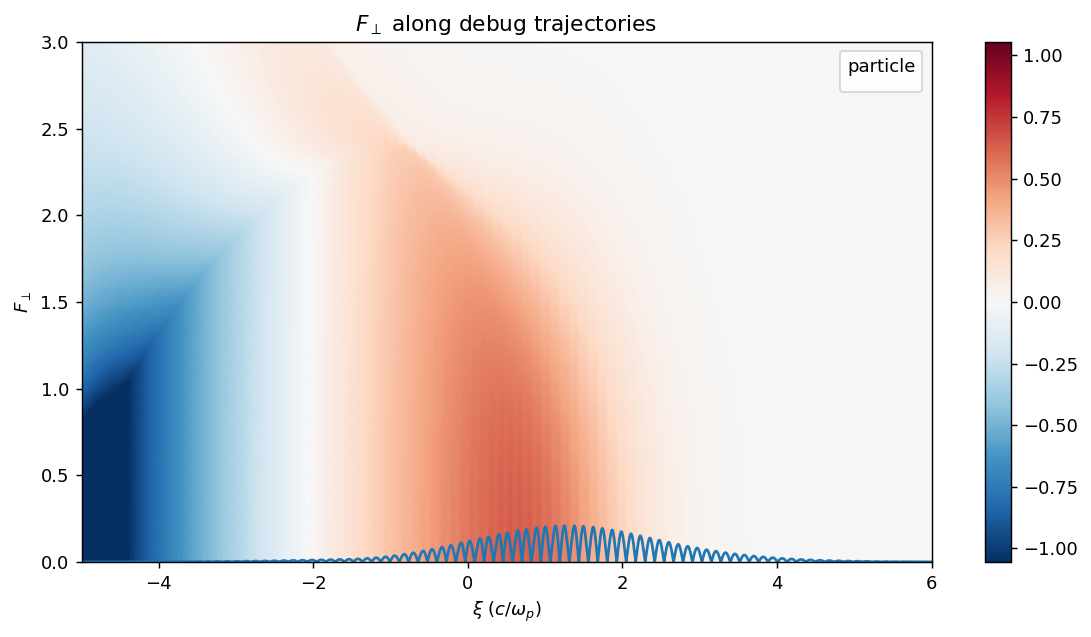

In [151]:
plot_field_with_debug_trajectories(
    debug_objects=debug,
    xi_axis=sim.xiaxis_1,
    y_axis=sim.raxis_1,
    field=sim.E1_M0,
    trajectory_quantity=lambda debug: np.sqrt(debug.Fx_dat**2 + debug.Fy_dat**2)/80,
    trajectory_label=r"$F_\perp$",
    title=r"$F_\perp$ along debug trajectories",
    xlim=(-5,6),
    ylim=(0,3),
    show_field=True,
)

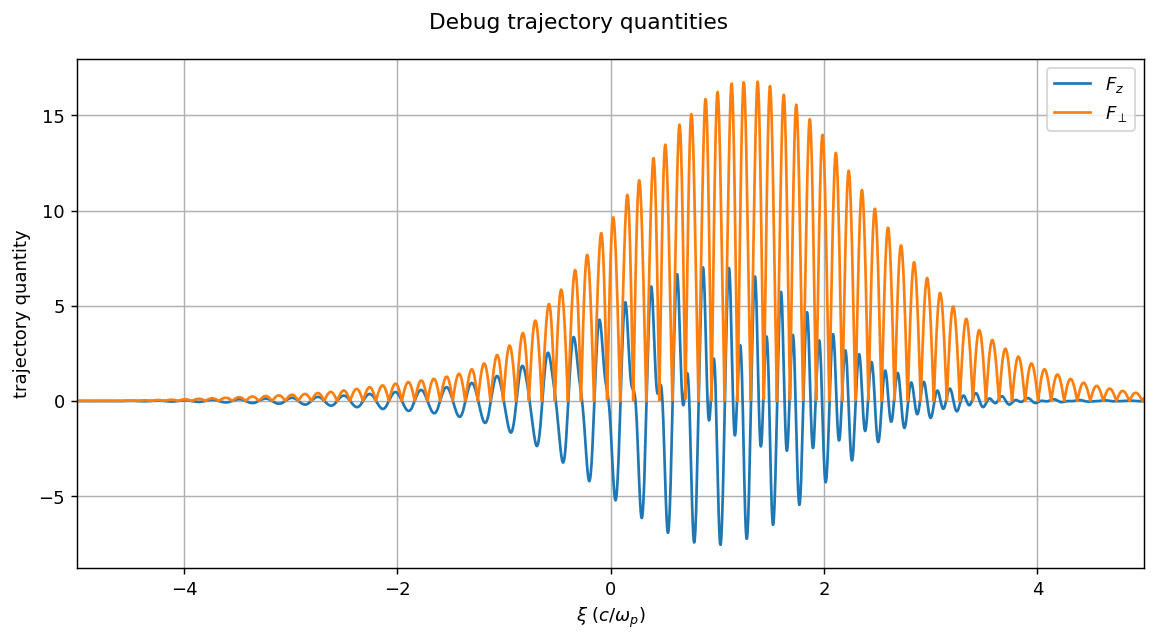

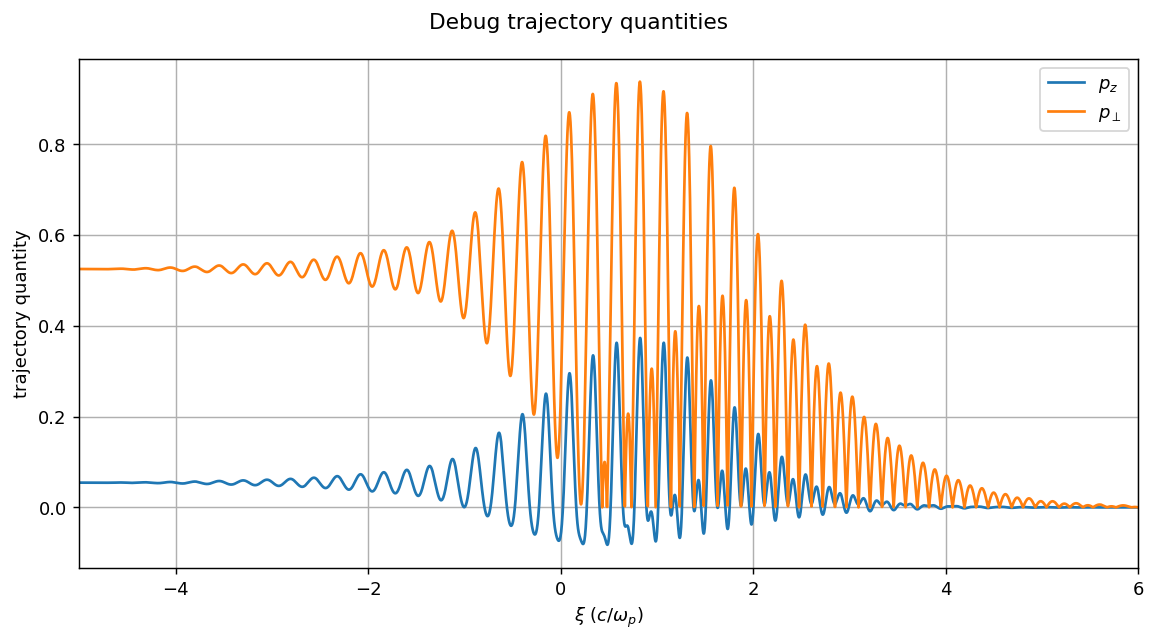

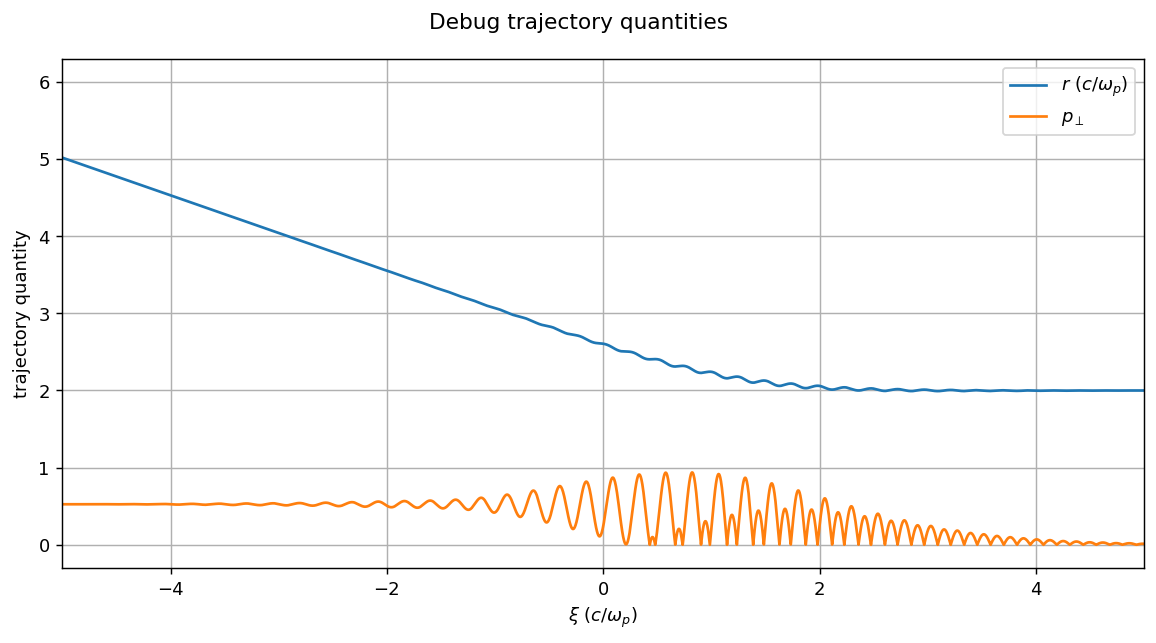

In [154]:
plot_debug_trajectory_quantities(
    debug_objects=debug,
    trajectory_quantities=[
        # (r"$x$ $(c/\omega_p)$", "x_dat"),
        # (r"$y$ $(c/\omega_p)$", "y_dat"),
        # (r"$F_x$", "Fx_dat"),
        # (r"$F_y$", "Fy_dat"),
        (r"$F_z$", "Fz_dat"),
        (
            r"$F_\perp$",
            lambda debug: np.sqrt(debug.Fx_dat**2 + debug.Fy_dat**2),
        ),
    ],
    title="Debug trajectory quantities",
    xlim=(-5, 5),
    use_separate_axes=False,
)

plot_debug_trajectory_quantities(
    debug_objects=debug,
    trajectory_quantities=[
        # (r"$x$ $(c/\omega_p)$", "x_dat"),
        # (r"$y$ $(c/\omega_p)$", "y_dat"),
        # (r"$F_x$", "Fx_dat"),
        # (r"$F_y$", "Fy_dat"),
        (r"$p_z$", "pz_dat"),
        (
            r"$p_\perp$",
            lambda debug: np.sqrt(debug.px_dat**2 + debug.py_dat**2),
        ),
    ],
    title="Debug trajectory quantities",
    # xlim=(-2, 0),
    xlim=(-5,6),
    use_separate_axes=False,
)

plot_debug_trajectory_quantities(
    debug_objects=debug,
    trajectory_quantities=[
        (r"$r$ $(c/\omega_p)$", "r_dat"),
        # (r"$y$ $(c/\omega_p)$", "y_dat"),
        # (r"$F_x$", "Fx_dat"),
        # (r"$F_y$", "Fy_dat"),
        # (r"$p_z$", "pz_dat"),
        (
            r"$p_\perp$",
            lambda debug: np.sqrt(debug.px_dat**2 + debug.py_dat**2),
        ),
    ],
    title="Debug trajectory quantities",
    xlim=(-5, 5),
    use_separate_axes=False,
)

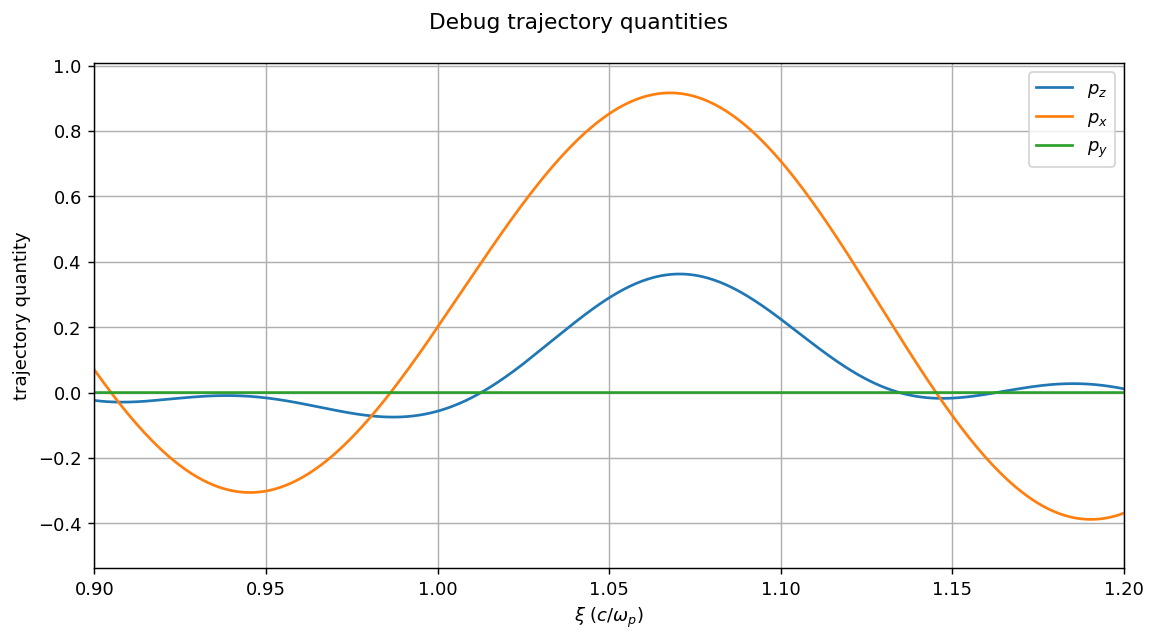

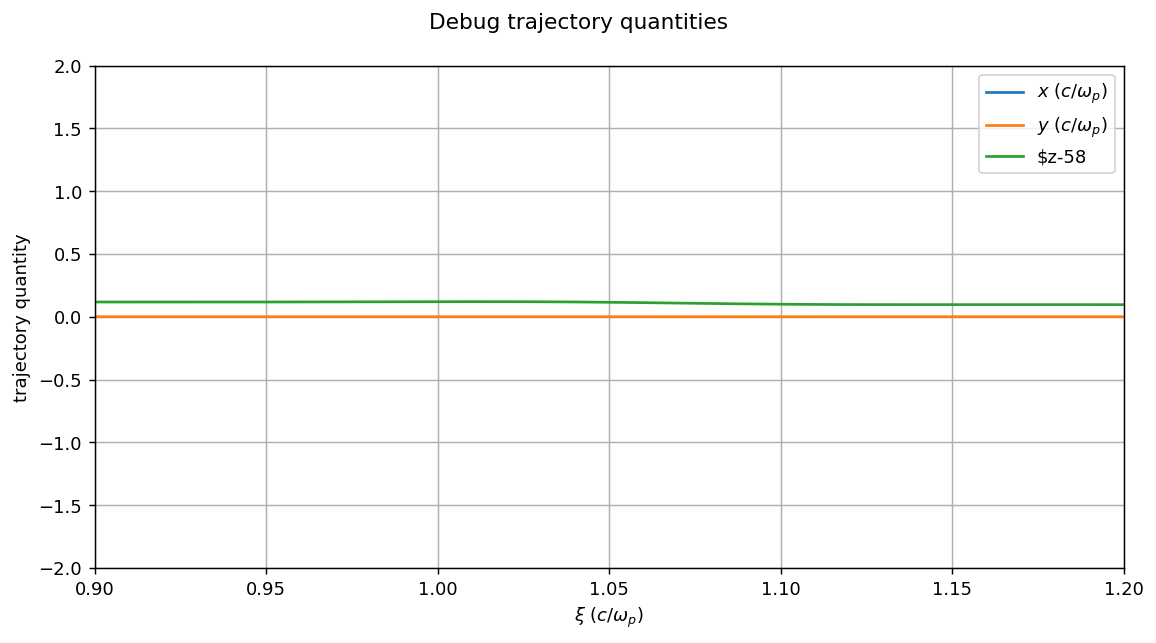

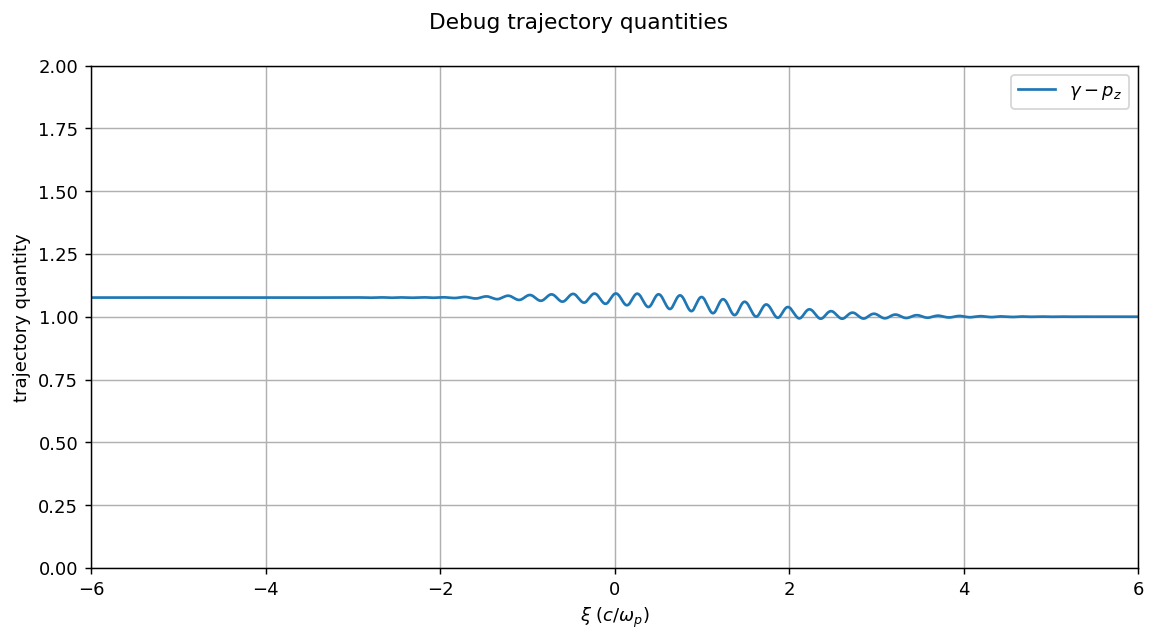

In [153]:
plot_debug_trajectory_quantities(
    debug_objects=debug,
    trajectory_quantities=[
        # (r"$x$ $(c/\omega_p)$", "x_dat"),
        # (r"$y$ $(c/\omega_p)$", "y_dat"),
        # (r"$F_x$", "Fx_dat"),
        # (r"$F_y$", "Fy_dat"),
        (r"$p_z$", "pz_dat"),
        (r"$p_x$", "px_dat"),
        (r"$p_y$", "py_dat"),
        # (
        #     r"$p_\perp$",
        #     lambda debug: np.sqrt(debug.px_dat**2 + debug.py_dat**2),
        # ),
    ],
    title="Debug trajectory quantities",
    # xlim=(0, 5.5),
    xlim=(0.9, 1.2),
    use_separate_axes=False,
)
plot_debug_trajectory_quantities(
    debug_objects=debug,
    trajectory_quantities=[
        (r"$x$ $(c/\omega_p)$", "x_dat"),
        (r"$y$ $(c/\omega_p)$", "y_dat"),
        (r"$z-58", lambda debug: debug.z_dat-58),
        # (r"$F_y$", "Fy_dat"),
        # (r"$p_z$", "pz_dat"),
        # (r"$p_x$", "px_dat"),
        # (r"$p_y$", "py_dat"),
        # # (
        #     r"$p_\perp$",
        #     lambda debug: np.sqrt(debug.px_dat**2 + debug.py_dat**2),
        # ),
    ],
    title="Debug trajectory quantities",
    # xlim=(0, 5.5),
    xlim=(0.9, 1.2),
    ylim=(-2,2),
    use_separate_axes=False,
)
#plot gamma-p_z
plot_debug_trajectory_quantities(
    debug_objects=debug,
    trajectory_quantities=[
        # (r"$x$ $(c/\omega_p)$", "x_dat"),
        # (r"$y$ $(c/\omega_p)$", "y_dat"),
        # (r"$z-58", lambda debug: debug.z_dat-58),
        # (r"$F_y$", "Fy_dat"),
        # (r"$p_z$", "pz_dat"),
        # (r"$p_x$", "px_dat"),
        # (r"$p_y$", "py_dat"),
        (
            r"$\gamma-p_z$",
            lambda debug: np.sqrt(1+debug.px_dat**2 + debug.py_dat**2+debug.pz_dat**2)-debug.pz_dat,
        ),
    ],
    title="Debug trajectory quantities",
    # xlim=(0, 5.5),
    xlim=(-6, 6),
    ylim=(0,2),
    use_separate_axes=False,
)

p_long shape: (23140,)
p_perp shape: (23140,)
p_long range: -1.6181670184925678 2.0538879366252223
p_perp range: -2.297763496358212 4.077415378511701


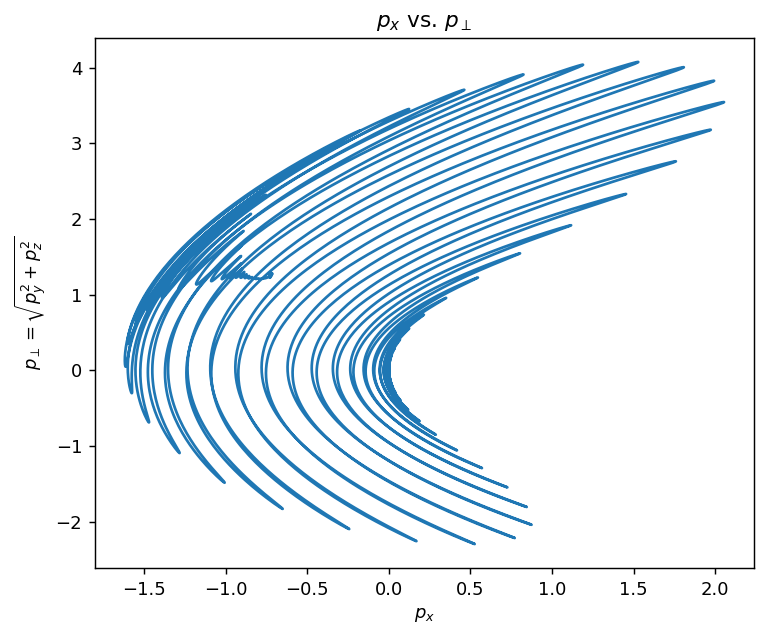

In [95]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=130)

px = np.asarray(debug.px_dat).squeeze()
py = np.asarray(debug.py_dat).squeeze()
pz = np.asarray(debug.pz_dat).squeeze()

p_long = pz
# p_perp = np.sqrt(py**2 + px**2)
p_perp=px

print("p_long shape:", p_long.shape)
print("p_perp shape:", p_perp.shape)
print("p_long range:", np.nanmin(p_long), np.nanmax(p_long))
print("p_perp range:", np.nanmin(p_perp), np.nanmax(p_perp))

ax.plot(p_long, p_perp, linewidth=1.5)

ax.set_xlabel(r"$p_x$")
ax.set_ylabel(r"$p_\perp = \sqrt{p_y^2 + p_z^2}$")
ax.set_title(r"$p_x$ vs. $p_\perp$")
fig.tight_layout()
plt.show()

p_long shape: (24366,)
p_perp shape: (24366,)
p_long range: -2.227712344453135 1.8435897907260836
p_perp range: 5.743135119504393e-08 2.3279034743096427


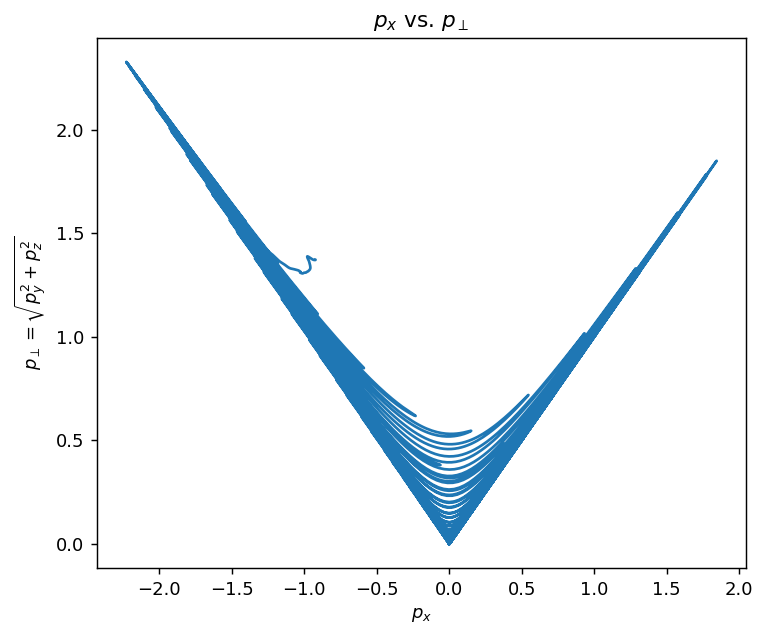

In [40]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=130)

px = np.asarray(debug.px_dat).squeeze()
py = np.asarray(debug.py_dat).squeeze()
pz = np.asarray(debug.pz_dat).squeeze()

p_long = pz
p_perp = np.sqrt(py**2 + pz**2)

print("p_long shape:", p_long.shape)
print("p_perp shape:", p_perp.shape)
print("p_long range:", np.nanmin(p_long), np.nanmax(p_long))
print("p_perp range:", np.nanmin(p_perp), np.nanmax(p_perp))

ax.plot(p_long, p_perp, linewidth=1.5)

ax.set_xlabel(r"$p_x$")
ax.set_ylabel(r"$p_\perp = \sqrt{p_y^2 + p_z^2}$")
ax.set_title(r"$p_x$ vs. $p_\perp$")
fig.tight_layout()
plt.show()